# Kiyohara public-transport isochrone analysis

This notebook creates 30-minute and 60-minute no-train / with-train public-transport accessibility polygons to the Kiyohara industrial-area LRT stop. It implements the requested travel-time workflow:

`area -> walk X min -> bus stop / rail node -> feeder bus Y min -> LRT stop -> LRT Z min -> destination`

Assumptions used by the workflow:

- `Z`: LRT travel time from each LRT stop to the destination, estimated from cumulative stop-to-stop route length in `lrt_stops.shp` at 20 km/h.
- `Y`: feeder-bus travel time from each bus stop through the N07 bus network at 20 km/h when available. This can include additive bus transfers, such as `bus -> bus -> LRT`, and direct `bus -> bus -> destination` paths.
- Rail: the with-train scenario loads `N05-25_RailroadSection2.shp` and `N05-25_Station2.shp`, clips them to the same analysis area, and estimates conventional rail travel with `RAIL_SPEED_M_PER_MIN = 40_000 / 60` when timetable travel times are unavailable.
- Waiting time: expected wait is average headway / 2. Bus boarding and bus re-boarding use `BUS_WAIT_TIME_MIN = 8`; LRT boarding uses `LRT_WAIT_TIME_MIN = 5`; rail boarding uses `RAIL_WAIT_TIME_MIN = 10`; `TRANSFER_PENALTY_MIN = 0` because physical transfer walking is represented by the route/road network. Wait penalties are applied when entering a bus, LRT, or rail route, not when alighting.
- `X`: remaining walking time, calculated as threshold minus transit travel time plus applicable wait penalties, and expanded along the road network when the required N13 road meshes are available.

The road-network step requires all four N13 road meshes and avoids simple circular buffers when they are present. If any required local data are missing, the notebook reports the missing inputs rather than silently fabricating results.


## Expected local/attached data

Place complete shapefile sets under `data/`, including `.shp`, `.shx`, `.dbf`, and `.prj` when available. The bus route map attached to the request should be available as:

- `data/N07-11_09_GML.shp` (plus sidecars)

The workflow also searches common alternatives recursively under `data/` for:

- `lrt_stops.shp` (required)
- `P11-22_09.shp` bus stop points (recommended)
- `N05-25_RailroadSection2.shp` railroad section lines (required for with-train scenario)
- `N05-25_Station2.shp` station points (required for with-train scenario)
- `N13-24_5439.shp`, `N13-24-5440.shp`, `N13-24-5539.shp`, and `N13-24-5540.shp` road lines (required for road-network walking isochrones across Utsunomiya)


In [4]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if str(REPO_ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "scripts"))

import kiyohara_transit_isochrone as iso

In [6]:
# Configure the destination stop.
# Use a more specific expression if the target should be a particular LRT stop,
# for example: r"清原地区市民センター前" or r"芳賀・高根沢工業団地".
DATA_DIR = "data"
OUTPUT_DIR = "outputs/kiyohara_isochrone"
TARGET_STOP_REGEX = r"清原地区市民センター前"
THRESHOLDS = [30, 60]


In [7]:
# Input discovery and sidecar check.
# This should print the resolved local layers before running the analysis.
iso.check_inputs(Path(DATA_DIR))


lrt_stops   : data/lrt_stops.shp
bus_stops   : data/P11-22_09.shp
bus_routes  : data/N07-11_09.shp
rail_lines  : data/N05-25_RailroadSection2.shp
rail_stations: data/N05-25_Station2.shp
roads       : 5 layer(s)
              - data/N13-24_5439.shp
              - data/N13-24_5440.shp
              - data/N13-24_5539.shp
              - data/N13-24_5540.shp
              - data/N05-25_RailroadSection2.shp
adm2        : data/gadm41_JPN_2.shp


True

In [8]:
# Run the full 30/60-minute isochrone analysis.
args = iso.parse_args([
    "--data-dir", DATA_DIR,
    "--output-dir", OUTPUT_DIR,
    "--target-stop-regex", TARGET_STOP_REGEX,
    "--thresholds", *map(str, THRESHOLDS),
])
iso.run_analysis(args)


lrt_stops   : data/lrt_stops.shp
bus_stops   : data/P11-22_09.shp
bus_routes  : data/N07-11_09.shp
rail_lines  : data/N05-25_RailroadSection2.shp
rail_stations: data/N05-25_Station2.shp
roads       : 5 layer(s)
              - data/N13-24_5439.shp
              - data/N13-24_5440.shp
              - data/N13-24_5539.shp
              - data/N13-24_5540.shp
              - data/N05-25_RailroadSection2.shp
adm2        : data/gadm41_JPN_2.shp


/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured LineString' is converted to 'LineString'
  return ogr_read(
/home/miwatanabe/private/UtsunomiyaLRT/scripts/kiyohara_transit_isochrone.py:1166: UserWarning: N07-11_09.shp has no CRS; assuming EPSG:6668.
  bus_routes = explode_lines(read_layer(layers["bus_routes"])) if layers["bus_routes"] else None



Destination LRT stop: 清原地区市民センター前


/home/miwatanabe/private/UtsunomiyaLRT/scripts/kiyohara_transit_isochrone.py:1046: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  layer.to_file(shp_dir / f"kiyohara_isochrone_{threshold}min.shp", encoding="utf-8")
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'threshold_min' to 'threshold_'
  ogr_write(
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'access_nodes' to 'access_nod'
  ogr_write(
/home/miwatanabe/private/UtsunomiyaLRT/scripts/kiyohara_transit_isochrone.py:1046: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  layer.to_file(shp_dir / f"kiyohara_isochrone_{threshold}min.shp", encoding="utf-8")
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'threshold_min' to 'threshold_'
  ogr_write(
/


Wrote outputs to outputs/kiyohara_isochrone
30 min no-train isochrone area: 21.87 km2 (road_network)
60 min no-train isochrone area: 190.19 km2 (road_network)
30 min with-train isochrone area: 24.35 km2 (road_network)
60 min with-train isochrone area: 190.33 km2 (road_network)


0

## Outputs

Expected outputs are written under `outputs/kiyohara_isochrone/`:

- `kiyohara_transit_isochrones.gpkg` with `isochrone_30min`, `isochrone_60min`, `access_nodes`, and `lrt_travel_times` layers
- `shapefiles/kiyohara_isochrone_30min.shp` and `shapefiles/kiyohara_isochrone_60min.shp`
- `tables/kiyohara_transit_access_nodes.csv` and `tables/kiyohara_lrt_travel_times.csv`
- `figures/kiyohara_transit_isochrones.png`


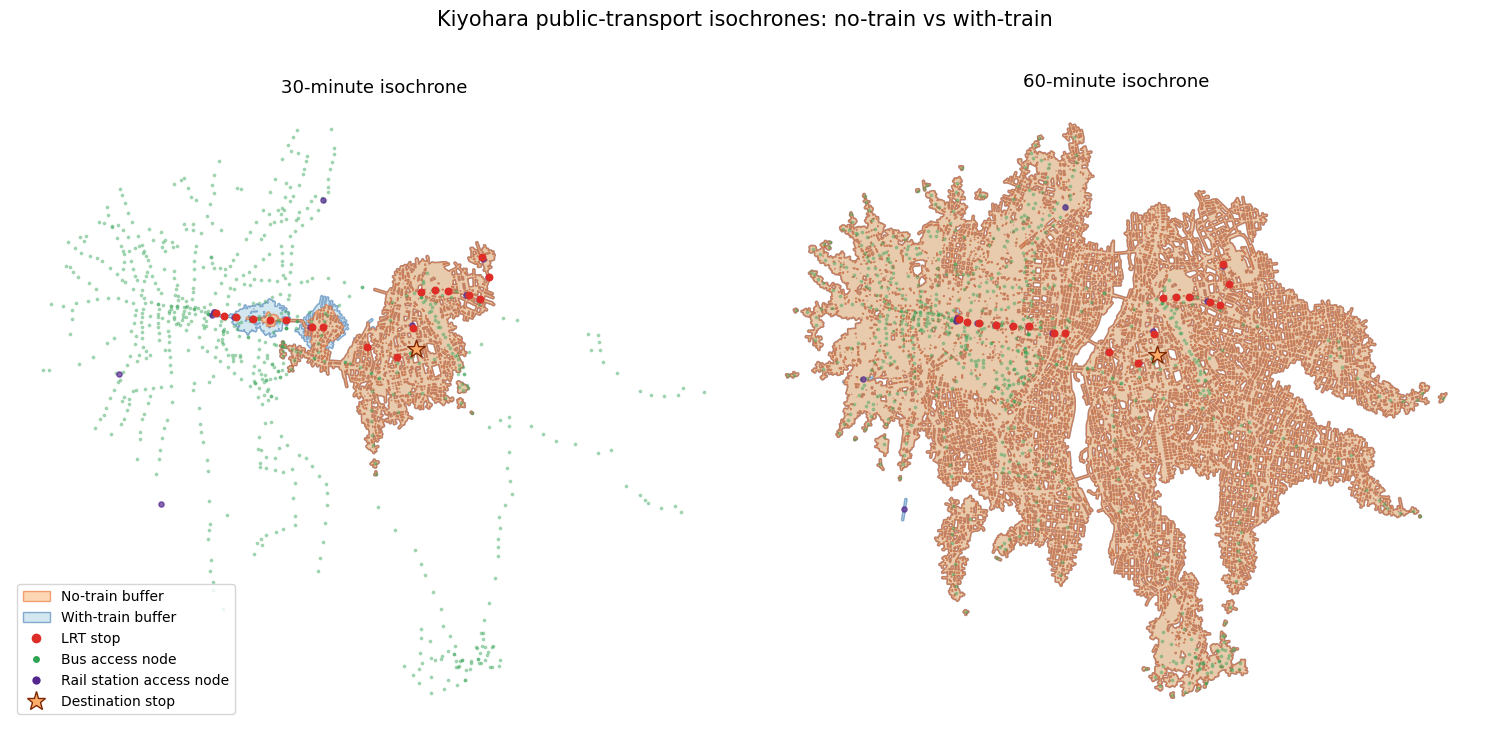

Saved map to outputs/kiyohara_isochrone/figures/kiyohara_isochrone_no_train_with_train_map.png


In [9]:
# Plot no-train and with-train 30/60-minute isochrones.
# Run the full analysis cell above first so the GeoPackage output exists.
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

output_dir = Path(OUTPUT_DIR)
gpkg_path = output_dir / "kiyohara_transit_isochrones.gpkg"
figure_path = output_dir / "figures" / "kiyohara_isochrone_no_train_with_train_map.png"

if not gpkg_path.exists():
    raise FileNotFoundError(
        f"{gpkg_path} was not found. Run the previous analysis cell before plotting."
    )

thresholds = [30, 60]
iso_no_train = {
    t: gpd.read_file(gpkg_path, layer=f"isochrone_{t}min")
    for t in thresholds
}
iso_with_train = {
    t: gpd.read_file(gpkg_path, layer=f"isochrone_with_train_{t}min")
    for t in thresholds
}
access_nodes = gpd.read_file(gpkg_path, layer="access_nodes_with_train")
lrt_travel_times = gpd.read_file(gpkg_path, layer="lrt_travel_times")

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

for ax, threshold in zip(axes, thresholds):
    # Draw the with-train area first, then overlay the no-train area.
    iso_with_train[threshold].plot(
        ax=ax,
        color="#9ecae1",
        edgecolor="#08519c",
        linewidth=1.1,
        alpha=0.45,
    )
    iso_no_train[threshold].plot(
        ax=ax,
        color="#fdae6b",
        edgecolor="#e6550d",
        linewidth=1.1,
        alpha=0.50,
    )

    if not access_nodes.empty:
        bus_nodes = access_nodes[access_nodes["access_type"].eq("bus_stop")]
        rail_nodes = access_nodes[access_nodes["access_type"].eq("rail_station")]
        lrt_nodes = access_nodes[access_nodes["access_type"].eq("lrt_stop")]
        if not bus_nodes.empty:
            bus_nodes.plot(ax=ax, color="#31a354", markersize=3, alpha=0.35)
        if not rail_nodes.empty:
            rail_nodes.plot(ax=ax, color="#54278f", markersize=14, alpha=0.70)
        if not lrt_nodes.empty:
            lrt_nodes.plot(ax=ax, color="#de2d26", markersize=22)

    if "is_destination_stop" in lrt_travel_times.columns:
        destination = lrt_travel_times[lrt_travel_times["is_destination_stop"].astype(bool)]
        if not destination.empty:
            destination.plot(ax=ax, marker="*", color="#fdae6b", edgecolor="#7f2704", markersize=180)

    ax.set_title(f"{threshold}-minute isochrone", fontsize=13)
    ax.set_axis_off()
    ax.set_aspect("equal")

legend_handles = [
    Patch(facecolor="#fdae6b", edgecolor="#e6550d", alpha=0.50, label="No-train buffer"),
    Patch(facecolor="#9ecae1", edgecolor="#08519c", alpha=0.45, label="With-train buffer"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#de2d26", markersize=8, label="LRT stop"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#31a354", markersize=6, label="Bus access node"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#54278f", markersize=7, label="Rail station access node"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="#fdae6b", markeredgecolor="#7f2704", markersize=14, label="Destination stop"),
]
axes[0].legend(handles=legend_handles, loc="lower left", frameon=True)
fig.suptitle("Kiyohara public-transport isochrones: no-train vs with-train", fontsize=15)

figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.tight_layout()
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved map to {figure_path}")


In [10]:
# Plot both 30-minute and 60-minute isochrones on one map.
# Run the full analysis cell above first so the GeoPackage output exists.
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

output_dir = Path(OUTPUT_DIR)
gpkg_path = output_dir / "kiyohara_transit_isochrones.gpkg"
figure_path1 = output_dir / "figures" / "kiyohara_isochrone_30_60_map_Post_withTrain.png"
figure_path2 = output_dir / "figures" / "kiyohara_isochrone_30_60_map_Post_noTrain.png"

if not gpkg_path.exists():
    raise FileNotFoundError(
        f"{gpkg_path} was not found. Run the previous analysis cell before plotting."
    )

thresholds = [30, 60]
iso_no_train = {
    t: gpd.read_file(gpkg_path, layer=f"isochrone_{t}min")
    for t in thresholds
}
iso_with_train = {
    t: gpd.read_file(gpkg_path, layer=f"isochrone_with_train_{t}min")
    for t in thresholds
}
access_nodes = gpd.read_file(gpkg_path, layer="access_nodes_with_train")
lrt_travel_times = gpd.read_file(gpkg_path, layer="lrt_travel_times")

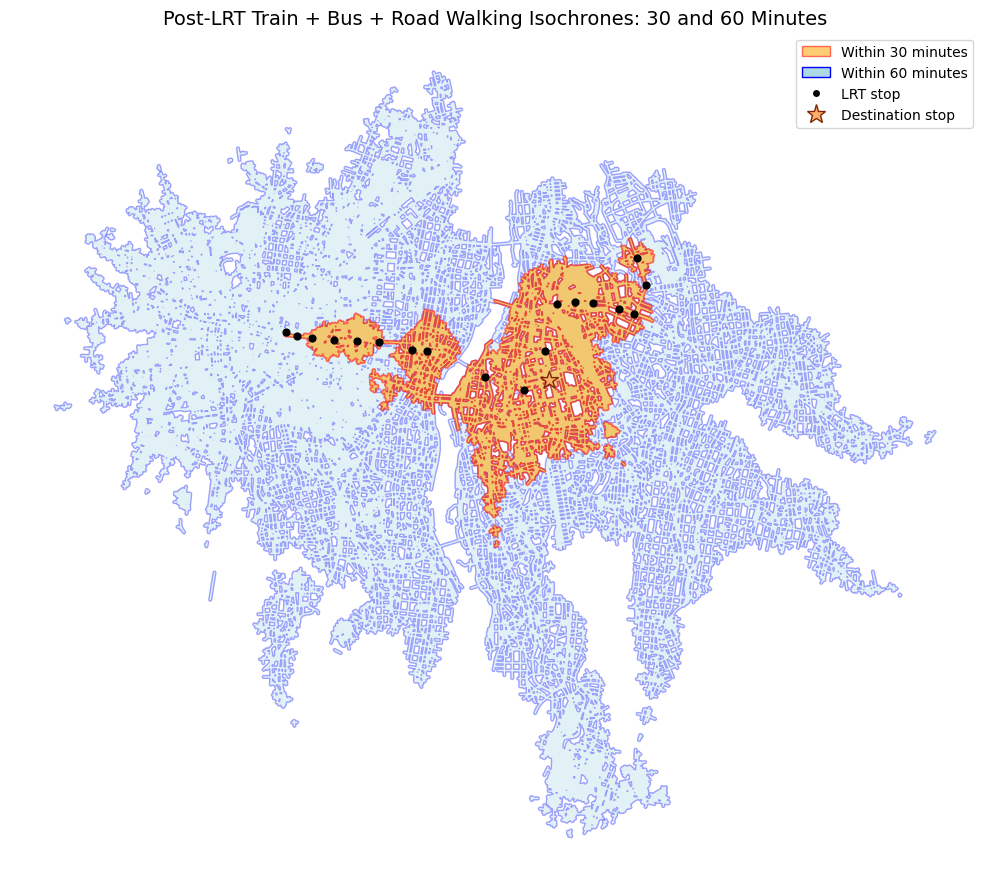

Saved map to outputs/kiyohara_isochrone/figures/kiyohara_isochrone_30_60_map_Post_withTrain.png


In [12]:
# Train + LRT + Bus + Walk
fig, ax = plt.subplots(figsize=(10, 10))

# Draw 60 minutes first so the 30-minute area is visible on top.
iso_with_train[60].plot(ax=ax, color="Lightblue", edgecolor="Blue", linewidth=1.0, alpha=0.35)
iso_with_train[30].plot(ax=ax, color="Orange", edgecolor="Red", linewidth=1.2, alpha=0.55)


if not access_nodes.empty:
    bus_nodes = access_nodes[~access_nodes["access_type"].eq("lrt_stop")]
    lrt_nodes = access_nodes[access_nodes["access_type"].eq("lrt_stop")]
    rail_nodes = access_nodes[access_nodes["access_type"].eq("rail_station")]
    # if not bus_nodes.empty:
    #     bus_nodes.plot(ax=ax, color="#31a354", markersize=4, alpha=0.45)
    # if not rail_nodes.empty:
    #         rail_nodes.plot(ax=ax, color="#54278f", markersize=14, alpha=0.70)
    if not lrt_nodes.empty:
        lrt_nodes.plot(ax=ax, color="Black", markersize=24)

if "is_destination_stop" in lrt_travel_times.columns:
    destination = lrt_travel_times[lrt_travel_times["is_destination_stop"].astype(bool)]
    if not destination.empty:
        destination.plot(ax=ax, marker="*", color="#fdae6b", edgecolor="#7f2704", markersize=180)

ax.set_title("Post-LRT Train + Bus + Road Walking Isochrones: 30 and 60 Minutes", fontsize=14)
ax.set_axis_off()
ax.set_aspect("equal")

legend_handles = [
    Patch(facecolor="Orange", edgecolor="Red", alpha=0.55, label="Within 30 minutes"),
    Patch(facecolor="Lightblue", edgecolor="Blue", label="Within 60 minutes"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="Black", markersize=6, label="LRT stop"),
    #Line2D([0], [0], marker="o", color="w", markerfacecolor="#31a354", markersize=6, label="Bus access node"),
    #Line2D([0], [0], marker="o", color="w", markerfacecolor="#54278f", markersize=7, label="Rail station access node"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="#fdae6b", markeredgecolor="#7f2704", markersize=14, label="Destination stop"),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=True)

figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.tight_layout()
fig.savefig(figure_path1, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved map to {figure_path1}")

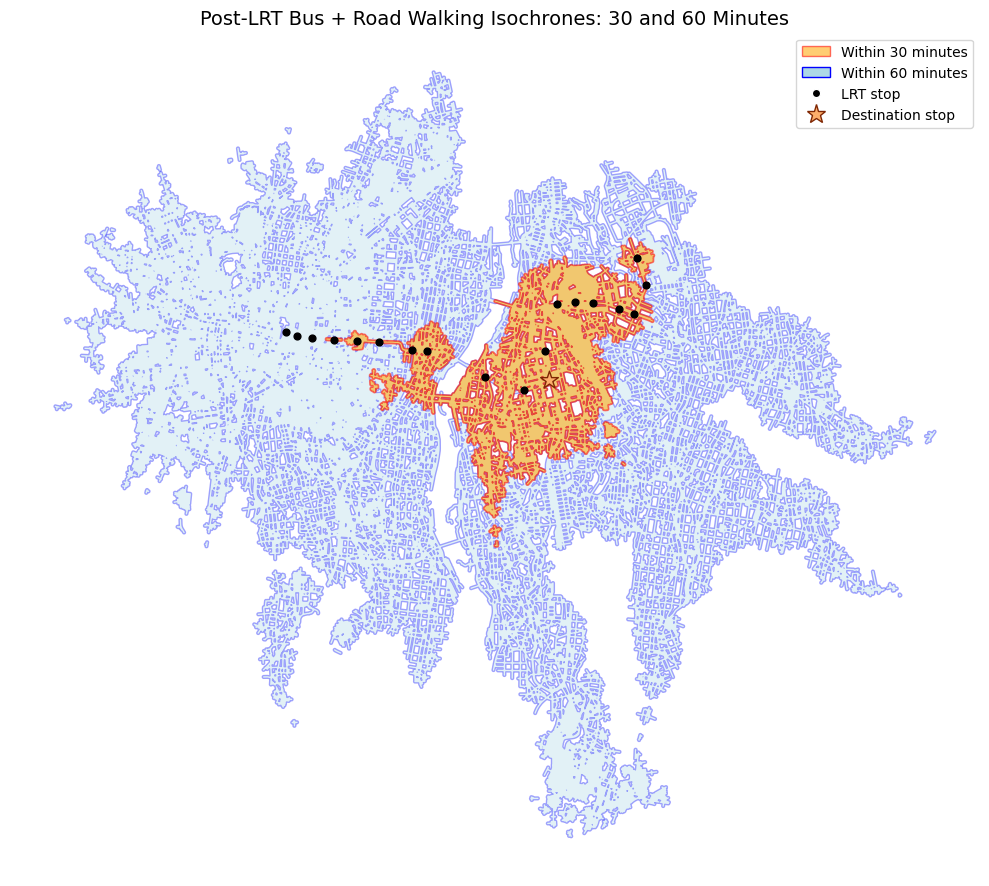

Saved map to outputs/kiyohara_isochrone/figures/kiyohara_isochrone_30_60_map_Post_noTrain.png


In [13]:
# LRT + Bus + Walk (No Train)
fig, ax = plt.subplots(figsize=(10, 10))

# Draw 60 minutes first so the 30-minute area is visible on top.
iso_no_train[60].plot(ax=ax, color="Lightblue", edgecolor="Blue", linewidth=1.0, alpha=0.35)
iso_no_train[30].plot(ax=ax, color="Orange", edgecolor="Red", linewidth=1.2, alpha=0.55)


if not access_nodes.empty:
    bus_nodes = access_nodes[~access_nodes["access_type"].eq("lrt_stop")]
    lrt_nodes = access_nodes[access_nodes["access_type"].eq("lrt_stop")]
    # if not bus_nodes.empty:
    #     bus_nodes.plot(ax=ax, color="#31a354", markersize=4, alpha=0.45)
    if not lrt_nodes.empty:
        lrt_nodes.plot(ax=ax, color="Black", markersize=24)

if "is_destination_stop" in lrt_travel_times.columns:
    destination = lrt_travel_times[lrt_travel_times["is_destination_stop"].astype(bool)]
    if not destination.empty:
        destination.plot(ax=ax, marker="*", color="#fdae6b", edgecolor="#7f2704", markersize=180)

ax.set_title("Post-LRT Bus + Road Walking Isochrones: 30 and 60 Minutes", fontsize=14)
ax.set_axis_off()
ax.set_aspect("equal")

legend_handles = [
    Patch(facecolor="Orange", edgecolor="Red", alpha=0.55, label="Within 30 minutes"),
    Patch(facecolor="Lightblue", edgecolor="Blue", label="Within 60 minutes"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="Black", markersize=6, label="LRT stop"),
    #Line2D([0], [0], marker="o", color="w", markerfacecolor="#31a354", markersize=6, label="Bus access node"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="#fdae6b", markeredgecolor="#7f2704", markersize=14, label="Destination stop"),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=True)

figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.tight_layout()
fig.savefig(figure_path2, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved map to {figure_path2}")